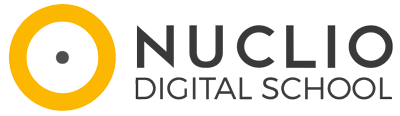

# ***Market Analysis for the Opening of Specialized Weightlifting Centers***

***Lift & Lead*** is a startup interested in opening training centers specializing in weightlifting. Given the rise of CrossFit—which incorporates weightlifting techniques—the founders believe this may be a good time to invest in centers dedicated exclusively to this sport.

The management team at ***Lift & Lead*** seeks to validate the hypothesis that the popularity of CrossFit is driving interest in weightlifting in Europe.

Currently, they don’t have much knowledge on the subject, and to begin better understanding the weightlifting sector and its athletes, they have assigned you the task of analyzing the results of the European weightlifting championships.

The analysis will be conducted in two phases:



1. **Phase 1**: You have been granted access to the 2019 and 2020 databases
  - The information was obtained via the following links by the former data analyst who has left the company:
    - https://es.wikipedia.org/wiki/Campeonato_Europeo_de_Halterofilia_de_2019
    - https://es.wikipedia.org/wiki/Campeonato_Europeo_de_Halterofilia_de_2020

2. **Phase 2:** They want to expand the analysis to cover a broader time frame, from 2019 to 2024, but they do not have the information. To obtain it, you will use web scraping on the following links:
    - https://es.wikipedia.org/wiki/Campeonato_Europeo_de_Halterofilia_de_2021
    - https://es.wikipedia.org/wiki/Campeonato_Europeo_de_Halterofilia_de_2022
    - https://es.wikipedia.org/wiki/Campeonato_Europeo_de_Halterofilia_de_2023
    - https://es.wikipedia.org/wiki/Campeonato_Europeo_de_Halterofilia_de_2024


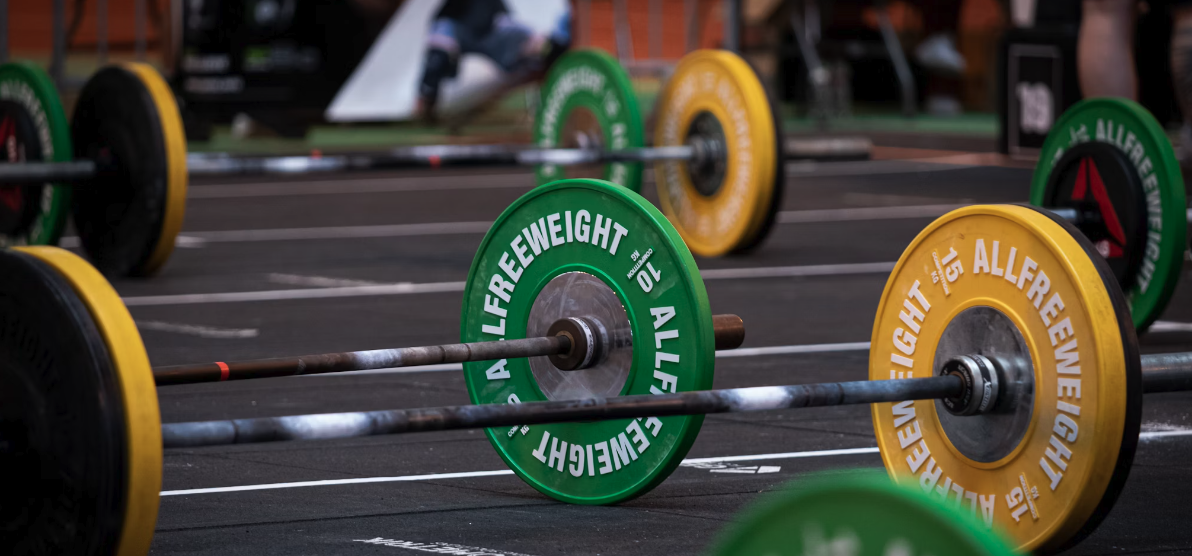

# **Part 1.**

## Step 1. Import libraries

In [2]:
import pandas as pd
import numpy as np

import re


import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px



import missingno as msno

import os

## Paso 2. Cargar datos

In [3]:
# Define the relative path to the data folder

data_directory = os.path.join("..", "data")

# Dictionary to store the datasets dynamically
datasets_dict = {}

# List all files in the target data directory
files_list = os.listdir(data_directory)

for file_name in files_list:
    # Process only CSV files to prevent system file pollution
    if file_name.endswith(".csv"):
        print(f"Successfully loaded: {file_name}")

        # Construct the absolute path safely regardless of the OS (Windows/Mac)
        file_path = os.path.join(data_directory, file_name)

        # Read and store the DataFrame using the filename as the key
        datasets_dict[file_name] = pd.read_csv(file_path)

Successfully loaded: European Weightlifting Championships 2019.csv
Successfully loaded: European Weightlifting Championships 2021.csv


## Step 3. Initial Exploration

In [4]:
datasets_dict.keys()

dict_keys(['European Weightlifting Championships 2019.csv', 'European Weightlifting Championships 2021.csv'])

In [5]:
#The below code is a helper function adapted from Master's course materials for automated EDA

def initial_exploration(df, mode = None):
    if mode == 'little_version':
        print("How many rows and columns are there in the dataset?")
        num_rows, num_columns = df.shape
        print("\tThere are {:,} rows and {:,} columns.".format(num_rows, num_columns))

        print("What are the first two rows of the dataset?")
        display(df.head(2))
        print('\n########################################################################################')
    else:
        print("¿How many rows and columns are there in the dataset?")
        num_rows, num_columns = df.shape
        print("\tThere are {:,} rows and {:,} columns.".format(num_rows, num_columns))
        print('\n########################################################################################')

        print("What are the first five rows of the dataset?")
        display(df.head())
        print('\n########################################################################################')

        print("What are the last five rows of the dataset?")
        display(df.tail())
        print('\n########################################################################################')

        print("How can you obtain a random sample of rows from the dataset?")
        display(df.sample(n = 5))
        print('\n########################################################################################')

        print("What are the columns in the dataset?")
        for i in list(df.columns):
            print('\t - ' + i)
        print('\n########################################################################################')

        print("What is the data type for each column?")
        print(df.dtypes)
        print('\n########################################################################################')

        print("How many columns are there for each type of data?")
        print(df.dtypes.value_counts())
        print('\n########################################################################################')

        print("How can we get more complete information about the structure and contents of the DataFrame?")
        print(df.info())
        print('\n########################################################################################')

        print("How many unique values does each column have?")
        print(df.nunique())
        print('\n########################################################################################')

        print("What are the basic descriptive statistics for all the columns?")
        display(df.describe(include = 'all').fillna(''))
        print('\n########################################################################################')

        print("Are there any null values in the dataset?")
        print(df.isnull().sum().sort_values(ascending = False))
        print('\n########################################################################################')

        print("What is the percentage of missing values in each column?")
        print(round((df.isnull().sum()/len(df)*100), 2).sort_values(ascending = False))
        print('\n########################################################################################')

In [6]:
for k, v in datasets_dict.items():
    initial_exploration(v)  


¿How many rows and columns are there in the dataset?
	There are 20 rows and 6 columns.

########################################################################################
What are the first five rows of the dataset?


,Events,Gold,Silver,Bronze,Year,Gender
0,55 kg (06.04),Mirco Scarantino Italy 116 + 145 = 261[n 1]​,Anguel Rusev Bulgaria 110 + 146 = 256[n 1]​,Muammer Şahin Turkey 112 + 135 = 247[n 1]​,2019,Masculine
1,61 kg (07.04),Henadz Laptseu Belarus 133 + 153 = 286,Bünyamin Sezer Turkey 132 + 151 = 283,Ferdi Hardal Turkey 127 + 155 = 282,2019,Masculine
2,67 kg (08.04),Bernardin Matam France 137 + 175 = 312,Simon Brandhuber Germany 146 + 165 = 311,Goga Chjeidze Georgia 139 + 169 = 308,2019,Masculine
3,73 kg (09.04),Bozhidar Andreev Bulgaria 153 + 192 = 345,Briken Calja Albania 156 + 183 = 339,Vadzim Lijarad Belarus 153 + 182 = 335,2019,Masculine
4,81 kg (10.04),Antonino Pizzolato Italy 155 + 201 = 356,Piotr Asayonak Belarus 159 + 196 = 355,Ritvars Suharevs Latvia 162 + 192 = 354,2019,Masculine



########################################################################################
What are the last five rows of the dataset?


,Events,Gold,Silver,Bronze,Year,Gender
15,71 kg (10.04),Anastasiya Romanova Russia 112 + 128 = 240,Emily Godley UK 93 + 123 = 216,Mădălina Molie Romania 101 + 114 = 215,2019,Femenine
16,76 kg (11.04),Daria Naumava Belarus 106 + 136 = 242,Lidia Valentín[2]​ Spain 108 + 133 = 241,Patricia Strenius Sweden 101 + 132 = 233,2019,Femenine
17,81 kg[n 2]​ (12.04),Nina Schroth Germany 102 + 120 = 222,Anna Van Bellinghen Belgium 103 + 118 = 221,Liana Guiurdzhian Armenia 97 + 120 = 217,2019,Femenine
18,87 kg (12.04),Xeniya Pasjina Russia 110 + 132 = 242,Diana Mstiyeva Russia 110 + 130 = 240,Sarah Fischer Austria 102 + 129 = 231,2019,Femenine
19,87 kg (13.04),Tatiana Kashirina Russia 146 + 185 = 331,Anastasiya Lysenko Ukraine 120 + 148 = 268,Emily Campbell UK 115 + 145 = 260,2019,Femenine



########################################################################################
How can you obtain a random sample of rows from the dataset?


...


########################################################################################
How can you obtain a random sample of rows from the dataset?


,Events,Gold,Silver,Bronze,Year,Gender
1,61 kg (04.04),Stilian Grozdev Bulgaria 136 + 160 = 296,Shota Mishvelidze Georgia 135 + 155 = 290,Ferdi Hardal Turkey 130 + 157 = 287,2020,Masculine
12,55 kg (04.04),Kamila Konotop Ukraine 95 + 113 = 208,Svetlana Yershova Russia 88 + 112 = 200,Nina Sterckx Belgium 88 + 109 = 197,2020,Femenine
17,81 kg (09.04),Alina Marushchak Ukraine 109 + 127 = 236,Gaëlle Nayo-Ketchanke France 100 + 131 = 231,Liana Guiurdzhian Armenia 98 + 129 = 227,2020,Femenine
11,49 kg (03.04),Monica Csengeri Romania 86 + 103 = 189,Kristina Sobol Russia 85 + 96 = 181,Mihaela Cambei Romania 80 + 100 = 180,2020,Femenine
19,+87 kg (11.04),Emily Campbell UK 122 + 154 = 276,Anastasiya Lysenko Ukraine 116 + 136 = 252,Melike Günal Turkey 108 + 135 = 243,2020,Femenine



########################################################################################
What are the columns in the dataset?
	 - Events
	 - Gold
	 - Silver
	 - Bronze
	 - Year
	 - Gender

########################################################################################
What is the data type for each column?
Events    object
Gold      object
Silver    object
Bronze    object
Year       int64
Gender    object
dtype: object

########################################################################################
How many columns are there for each type of data?
object    5
int64     1
Name: count, dtype: int64

########################################################################################
How can we get more complete information about the structure and contents of the DataFrame?
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Events  20 non-

,Events,Gold,Silver,Bronze,Year,Gender
count,20,20,20,20,20.0,20
unique,19,20,20,20,,2
top,55 kg (04.04),Anguel Rusev Bulgaria 111 + 147 = 258[n 1]​,Valentin Iancu Romania 108 + 140 = 248[n 1]​,Dmytro Voronovsky Ukraine 110 + 137 = 247[n 1]​,,Masculine
freq,2,1,1,1,,10
mean,,,,,2020.0,
std,,,,,0.0,
min,,,,,2020.0,
25%,,,,,2020.0,
50%,,,,,2020.0,
75%,,,,,2020.0,



########################################################################################
Are there any null values in the dataset?
Events    0
Gold      0
Silver    0
Bronze    0
Year      0
Gender    0
dtype: int64

########################################################################################
What is the percentage of missing values in each column?
Events    0.0
Gold      0.0
Silver    0.0
Bronze    0.0
Year      0.0
Gender    0.0
dtype: float64

########################################################################################


The first trap in this exercise involves the **2020** CSV file. While the instructions state that the data covers 2019 and 2020. However upon analyzing the data, I discovered that the '2020' file actually contains amended data for 2021. Because the contest was canceled in 2020, the file and its references should be updated to reflect the correct year: 2021. This can be confirmed by opening the link to the **"2020"** file provided at the beginning of this notebook.

In [7]:
#renaming the dfs

df_2019 = datasets_dict['European Weightlifting Championships 2019.csv']
df_2021 = datasets_dict['European Weightlifting Championships 2021.csv']




In [8]:
#changing the year 2020 to 2021 in the df_2021

df_2021["Year"] = df_2021["Year"].replace(2020, 2021)

## Step 4. Creating a single dataframe with the data from 2019 and 2021

In [9]:
df = pd.concat([df_2019, df_2021])

## Step 5. Transforming the data

Transforming the DataFrame so that it contains the following columns: Events, Year, Gender, Medal (indicating whether it is Gold, Silver, or Bronze), and Athlete (containing information about the corresponding athlete)

Initial format:

| Events | Gold | Silver | Bronze | Year | Gender |
|---------|-----|-------|--------|-----|--------|

**Important!**
The final dataframe must have this format:

| Events | Year | Gender | Medal | Athlete |
|---------|-----|-------|--------|-----|

In [10]:
df.head()

,Events,Gold,Silver,Bronze,Year,Gender
0,55 kg (06.04),Mirco Scarantino Italy 116 + 145 = 261[n 1]​,Anguel Rusev Bulgaria 110 + 146 = 256[n 1]​,Muammer Şahin Turkey 112 + 135 = 247[n 1]​,2019,Masculine
1,61 kg (07.04),Henadz Laptseu Belarus 133 + 153 = 286,Bünyamin Sezer Turkey 132 + 151 = 283,Ferdi Hardal Turkey 127 + 155 = 282,2019,Masculine
2,67 kg (08.04),Bernardin Matam France 137 + 175 = 312,Simon Brandhuber Germany 146 + 165 = 311,Goga Chjeidze Georgia 139 + 169 = 308,2019,Masculine
3,73 kg (09.04),Bozhidar Andreev Bulgaria 153 + 192 = 345,Briken Calja Albania 156 + 183 = 339,Vadzim Lijarad Belarus 153 + 182 = 335,2019,Masculine
4,81 kg (10.04),Antonino Pizzolato Italy 155 + 201 = 356,Piotr Asayonak Belarus 159 + 196 = 355,Ritvars Suharevs Latvia 162 + 192 = 354,2019,Masculine


In [11]:
#Transforming the DataFrame so that it contains the following columns: Events, Year, Gender, Medal and Athlete

def columns_medals(mi_df):

    #Create a new data frame: my_df_gold. Rename the “Gold” column to “Athlete”

    my_df_gold = mi_df[["Events", "Year", "Gender", "Gold"]].rename(columns={"Gold": "Athlete"}) 
    my_df_gold["Medal"] = "Gold" #Añadir una columna nueva "Oro"


    #Do the same for my_df_silver and my_df_bronze

    my_df_silver = mi_df[["Events", "Year", "Gender", "Silver"]].rename(columns={"Silver": "Athlete"})
    my_df_silver["Medal"] = "Silver"


    my_df_bronze = mi_df[["Events", "Year", "Gender", "Bronze"]].rename(columns={"Bronze": "Athlete"})
    my_df_bronze["Medal"] = "Bronze"

    #Create one final df

    df_final = pd.concat([my_df_gold, my_df_silver, my_df_bronze])
    df_final = df_final.reset_index(drop=True)
    df_final = df_final[["Events", "Year", "Gender", "Medal", "Athlete"]]

    return df_final





In [12]:
df = columns_medals(df)

## Step 6. Creating Columns

**Important!**
The final dataframe must contain only the following columns:

| Gender    | Category | Date | Medal | Name | Surname | Country | Sprint | Two_stroke | Total |


In [13]:
df.columns

Index(['Events', 'Year', 'Gender', 'Medal', 'Athlete'], dtype='object')

In [14]:
df.head()

,Events,Year,Gender,Medal,Athlete
0,55 kg (06.04),2019,Masculine,Gold,Mirco Scarantino Italy 116 + 145 = 261[n 1]​
1,61 kg (07.04),2019,Masculine,Gold,Henadz Laptseu Belarus 133 + 153 = 286
2,67 kg (08.04),2019,Masculine,Gold,Bernardin Matam France 137 + 175 = 312
3,73 kg (09.04),2019,Masculine,Gold,Bozhidar Andreev Bulgaria 153 + 192 = 345
4,81 kg (10.04),2019,Masculine,Gold,Antonino Pizzolato Italy 155 + 201 = 356


In [15]:
#Reorganizing columns 

def split_columns(my_df):

    #Create the "Category" and "Date" columns.

    my_df[["Category", "Date"]] = my_df["Events"].str.split('(', n=1, expand=True)


    #Create the columns Name, Surname, Country, and an auxiliary column: Aux_column
    #The auxiliary column will later be used to create the columns Start, Two-Stroke, and Total, since the delimiter for these three columns is not a space. 

    my_df[["Name", "Surname", "Country", "Aux_column"]] = my_df["Athlete"].str.split(' ', n=3, expand=True) 


    #Extracting the Sprint values from the Aux_column

    my_df[["Sprint", "Aux_column"]] = my_df["Aux_column"].str.split('+', expand=True)

    #Dividing the Aux_column into Two_stroke and Total column
    
    my_df[["Two_stroke", "Total"]] = my_df["Aux_column"].str.split('=', expand=True) 

    return my_df


In [16]:
df = split_columns(df)

In [17]:
df.columns

Index(['Events', 'Year', 'Gender', 'Medal', 'Athlete', 'Category', 'Date',
       'Name', 'Surname', 'Country', 'Aux_column', 'Sprint', 'Two_stroke',
       'Total'],
      dtype='object')

In [18]:
#Concatenate the “date” and “year” columns

df["Date"] = df["Date"].astype(str)
df["Date"] = df["Date"] + "." + df["Year"].astype(str)

In [19]:
#Remove unnecessary parentheses from the “Date” column

df["Date"] = df["Date"].str.replace(")", "")

In [20]:
#Saving necessary columns

df = df[["Gender", "Category", "Date", "Medal", "Name", "Surname", "Country", "Sprint", "Two_stroke", "Total"]]

## Step 7. Data Cleaning

In [21]:
df.head()

,Gender,Category,Date,Medal,Name,Surname,Country,Sprint,Two_stroke,Total
0,Masculine,55 kg,06.04.2019,Gold,Mirco,Scarantino,Italy,116,145,261[n 1]​
1,Masculine,61 kg,07.04.2019,Gold,Henadz,Laptseu,Belarus,133,153,286
2,Masculine,67 kg,08.04.2019,Gold,Bernardin,Matam,France,137,175,312
3,Masculine,73 kg,09.04.2019,Gold,Bozhidar,Andreev,Bulgaria,153,192,345
4,Masculine,81 kg,10.04.2019,Gold,Antonino,Pizzolato,Italy,155,201,356


In [22]:
#Some values in the “Total” column contain unnecessary characters. That part will be removed.

df["Total"] = df["Total"].str.replace("[n1]", "")

In [23]:
df.head()

,Gender,Category,Date,Medal,Name,Surname,Country,Sprint,Two_stroke,Total
0,Masculine,55 kg,06.04.2019,Gold,Mirco,Scarantino,Italy,116,145,261[n 1]​
1,Masculine,61 kg,07.04.2019,Gold,Henadz,Laptseu,Belarus,133,153,286
2,Masculine,67 kg,08.04.2019,Gold,Bernardin,Matam,France,137,175,312
3,Masculine,73 kg,09.04.2019,Gold,Bozhidar,Andreev,Bulgaria,153,192,345
4,Masculine,81 kg,10.04.2019,Gold,Antonino,Pizzolato,Italy,155,201,356


In [24]:
#Convert the Date column to the "date" data type
df["Date"] = pd.to_datetime(df["Date"], format="%d.%m.%Y")

Checking for possible incorrect values in each column

In [25]:
def checking_unique_values(df):
    for column in df.columns:
       print(f"Columna: {column}")
       print(df[column].unique())
       print("__________________________")


In [26]:
checking_unique_values(df)

Columna: Gender
['Masculine' 'Femenine']
__________________________
Columna: Category
['55\xa0kg ' '61\xa0kg ' '67\xa0kg ' '73\xa0kg ' '81\xa0kg ' '89\xa0kg '
 '96\xa0kg ' '102\xa0kg ' '109\xa0kg ' '45\xa0kg ' '49\xa0kg ' '59\xa0kg '
 '64\xa0kg ' '71\xa0kg ' '76\xa0kg ' '81\xa0kg[n 2]\u200b ' '87\xa0kg '
 '+109\xa0kg ' '+87\xa0kg ']
__________________________
Columna: Date
<DatetimeArray>
['2019-04-06 00:00:00', '2019-04-07 00:00:00', '2019-04-08 00:00:00',
 '2019-04-09 00:00:00', '2019-04-10 00:00:00', '2019-04-11 00:00:00',
 '2019-04-12 00:00:00', '2019-04-13 00:00:00', '2021-04-04 00:00:00',
 '2021-04-05 00:00:00', '2021-04-06 00:00:00', '2021-04-07 00:00:00',
 '2021-04-08 00:00:00', '2021-04-09 00:00:00', '2021-04-10 00:00:00',
 '2021-04-11 00:00:00', '2021-04-03 00:00:00']
Length: 17, dtype: datetime64[ns]
__________________________
Columna: Medal
['Gold' 'Silver' 'Bronze']
__________________________
Columna: Name
['Mirco' 'Henadz' 'Bernardin' 'Bozhidar' 'Antonino' 'Hakob' 'Yauhen

In [27]:
#stripping unnecessary whitespace

df = df.apply(func=lambda col: col.str.strip() if col.dtypes == "object" else col)

In [28]:
#The "Category" column contains an unnecessary characters. That part will be removed.

df["Category"] = df["Category"].str.split("\xa0").str[0]
df["Category"] = df["Category"] + " kg"

In [29]:
#The "Total" column contains unnecessary characters. That part will be removed.

df["Total"] = df["Total"].str.replace("[n 1]", "")
df["Total"] = df["Total"].str.replace("\u200b", "")

#There is an incorrect value "Belgium" in the column sprint. This is probably due to the fact that the Athelte had two names or surnames and when splitting the column that fact was omitted.

In [30]:
df[df["Sprint"] == "Belgium  103"]

,Gender,Category,Date,Medal,Name,Surname,Country,Sprint,Two_stroke,Total
57,Femenine,81 kg,2019-04-12,Silver,Anna,Van,Bellinghen,Belgium 103,118,221


In [31]:
# I've determined that the unusual value is due to the fact that the athlete has two last names.
# I am fixing this row.

df["Surname"] = df["Surname"].apply(lambda x: x + " Bellinghen" if x == "Van" else x)
df["Country"] = df["Country"].apply(lambda x: "Belgium" if x == "Bellinghen" else x)
df["Sprint"] = df["Sprint"].astype(str).str.split(" ").str[-1]

In [32]:
# Print row 57 to verify the change

df.iloc[57]

Gender                   Femenine
Category                    81 kg
Date          2019-04-12 00:00:00
Medal                      Silver
Name                         Anna
Surname            Van Bellinghen
Country                   Belgium
Sprint                        103
Two_stroke                    118
Total                         221
Name: 57, dtype: object

## Step 8. Data Type

**Important!**
The column types must be as follows:

- **Gender**: `object`
- **Category**: `category`
- **Date**: `datetime64[ns]`
- **Medal**: `category`
- **Name**: `object`
- **Surname4**: `object`
- **Country**: `object`
- **Sprint**: `int64`
- **Two-Stroke**: `int64`
- **Total**: `int64`

In [33]:
df.dtypes

Gender                object
Category              object
Date          datetime64[ns]
Medal                 object
Name                  object
Surname               object
Country               object
Sprint                object
Two_stroke            object
Total                 object
dtype: object

In [34]:
df["Sprint"] = df["Sprint"].astype("int64")
df["Two_stroke"] = df["Two_stroke"].astype("int64")
df["Total"] = df["Total"].astype("int64")
df['Category'] = df['Category'].astype('category')
df['Medal'] = df['Medal'].astype('category')



In [35]:
df.dtypes

Gender                object
Category            category
Date          datetime64[ns]
Medal               category
Name                  object
Surname               object
Country               object
Sprint                 int64
Two_stroke             int64
Total                  int64
dtype: object

## Step 9. Sorting

The dataset will be sorted by the following columns:
[‘Gender’, ‘Medal’]. 

In [36]:
df.head()

,Gender,Category,Date,Medal,Name,Surname,Country,Sprint,Two_stroke,Total
0,Masculine,55 kg,2019-04-06,Gold,Mirco,Scarantino,Italy,116,145,261
1,Masculine,61 kg,2019-04-07,Gold,Henadz,Laptseu,Belarus,133,153,286
2,Masculine,67 kg,2019-04-08,Gold,Bernardin,Matam,France,137,175,312
3,Masculine,73 kg,2019-04-09,Gold,Bozhidar,Andreev,Bulgaria,153,192,345
4,Masculine,81 kg,2019-04-10,Gold,Antonino,Pizzolato,Italy,155,201,356


In [37]:
def sort(my_df):

    my_df["Medal"] = pd.Categorical(df["Medal"], categories=['Gold', 'Silver', 'Bronze'], ordered=True)

    sorted_df = my_df.sort_values(["Gender", "Medal"], ascending= True, ignore_index = True)

    return sorted_df

In [38]:
df = sort(df)

## Step 10. EDA
Conducting an exploratory analysis of the data to gain insight into the dataset.

In [39]:
df.describe()

,Date,Sprint,Two_stroke,Total
count,120,120.000000,120.000000,120.000000
mean,2020-04-07 21:36:00,129.600000,157.391667,286.991667
min,2019-04-06 00:00:00,67.000000,81.000000,150.000000
25%,2019-04-10 00:00:00,99.500000,122.000000,221.750000
50%,2020-04-07 12:00:00,114.500000,145.000000,257.000000
75%,2021-04-07 00:00:00,163.250000,200.000000,366.000000
max,2021-04-11 00:00:00,222.000000,263.000000,485.000000
std,NaN,38.603435,45.187061,83.566257


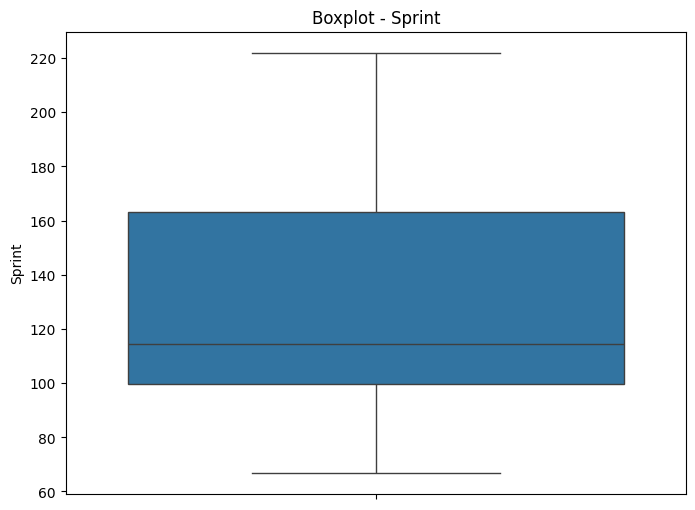

In [40]:
# Identifying Outliers: Sprint

plt.figure(figsize=(8, 6))
sns.boxplot(y=df['Sprint'])
plt.title("Boxplot - Sprint")
plt.show()

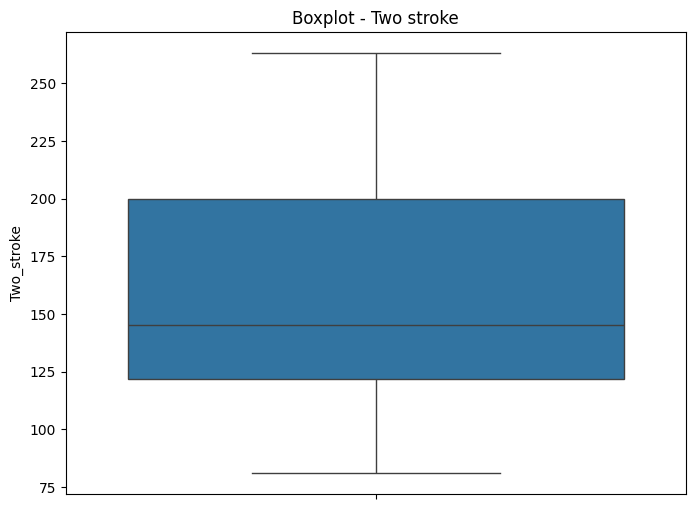

In [41]:
# Identifying Outliers: Two_stroke

plt.figure(figsize=(8, 6))
sns.boxplot(y=df["Two_stroke"])
plt.title('Boxplot - Two stroke')
plt.show()

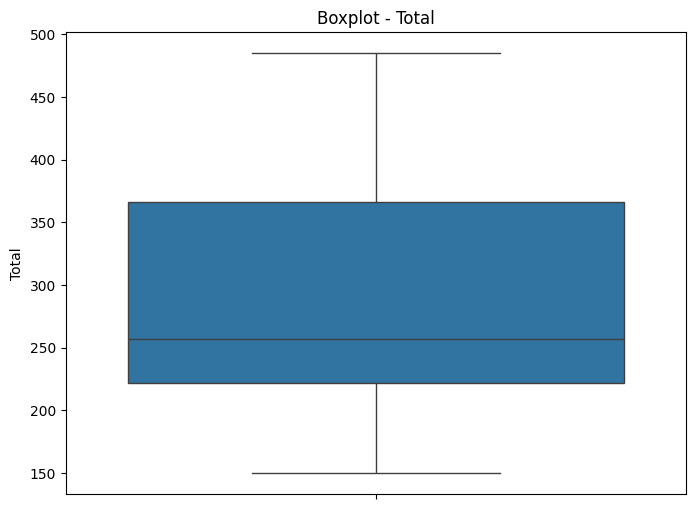

In [42]:
# Identifying Outliers: Total

plt.figure(figsize=(8, 6))
sns.boxplot(y=df['Total'])
plt.title("Boxplot - Total")
plt.show()

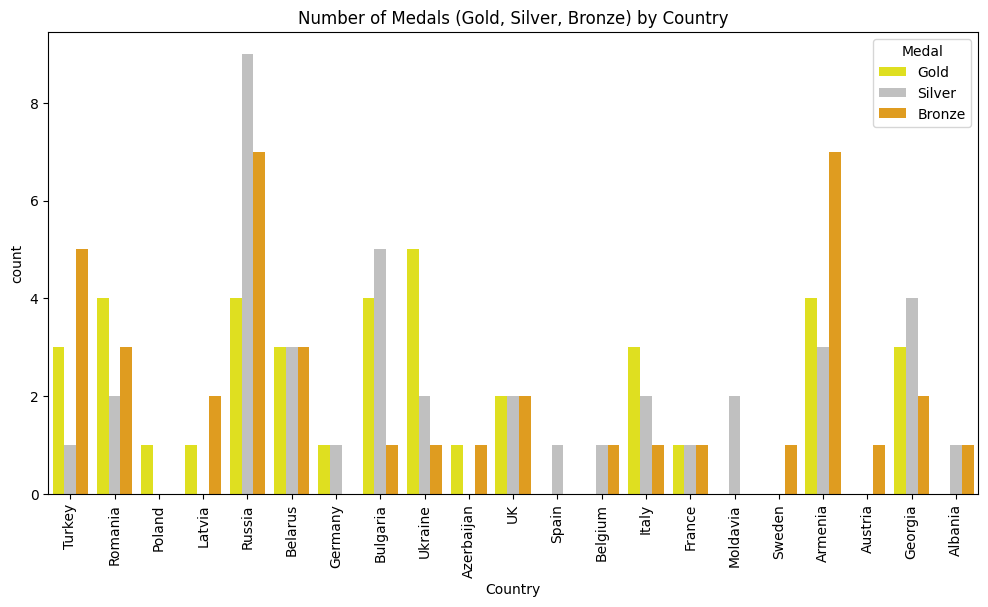

In [43]:
# Bar chart showing the number of medals (Gold, Silver, Bronze) by country

order_medals = ["Gold", "Silver", "Bronze"]

plt.figure(figsize=(12, 6))
sns.countplot(x="Country", 
              data=df, 
              hue="Medal",
              hue_order=order_medals,
              palette=["yellow", "silver", "Orange"])
plt.title("Number of Medals (Gold, Silver, Bronze) by Country")
plt.xticks(rotation=90)
plt.show()


C:\Users\Usuario\AppData\Local\Temp\ipykernel_7844\914141779.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="Gender",


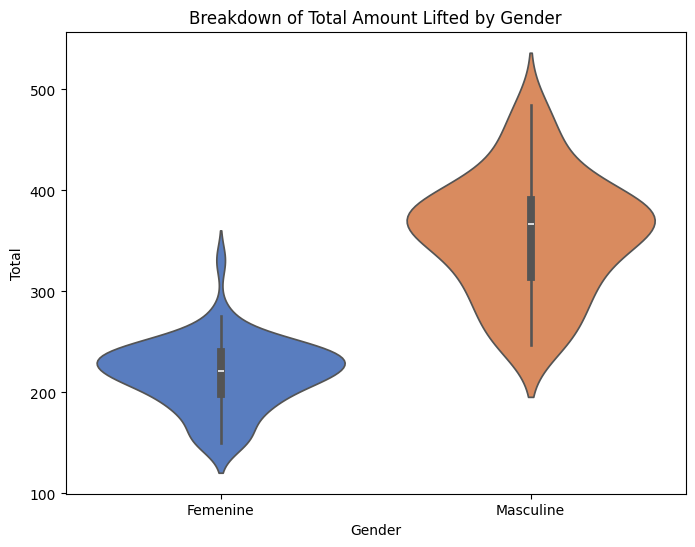

In [44]:
# Violin plot comparing the distribution of total kg lifted by gender

plt.figure(figsize=(8, 6))
sns.violinplot(x="Gender", 
               y="Total", 
               data=df, 
               palette="muted")
plt.title("Breakdown of Total Amount Lifted by Gender")
plt.show()



In [45]:
# Filter the athletes who have won a medal in both years

number_of_medals_per_athelte = df.groupby(["Name", "Surname"])["Medal"].size().sort_values(ascending=False).reset_index()

In [46]:
atheltes_with_two_medals = number_of_medals_per_athelte[number_of_medals_per_athelte["Medal"] == 2]
print(atheltes_with_two_medals)

          Name      Surname  Medal
0     Kristina        Sobol      2
1       Briken        Calja      2
2        Ferdi       Hardal      2
3        Emily       Godley      2
4        Emily     Campbell      2
5      Ritvars     Suharevs      2
6        Hakob    Mkrtchian      2
7        Revaz    Davitadze      2
8       Dmytro       Chumak      2
9        Piotr     Asayonak      2
10    Svetlana     Yershova      2
11       Ivana      Petrova      2
12      Samvel    Gasparian      2
13       Liana  Guiurdzhian      2
14      Anguel        Rusev      2
15       Lasha    Talajadze      2
16  Anastasiya      Lysenko      2
17  Anastasiya     Romanova      2
18    Loredana         Toma      2
19    Antonino    Pizzolato      2
20       Anton     Pliesnoi      2


## **Required Questions to Be Answered**

### How many medals of each type (gold, silver, and bronze) has each country won in the competition? (Regardless of gender)

In [47]:
df.head()

,Gender,Category,Date,Medal,Name,Surname,Country,Sprint,Two_stroke,Total
0,Femenine,45 kg,2019-04-06,Gold,Şaziye,Erdoğan,Turkey,75,88,163
1,Femenine,49 kg,2019-04-06,Gold,Elena,Andrieș,Romania,87,103,190
2,Femenine,55 kg,2019-04-07,Gold,Joanna,Łochowska,Poland,87,112,199
3,Femenine,59 kg,2019-04-08,Gold,Rebeka,Koha,Latvia,101,120,221
4,Femenine,64 kg,2019-04-09,Gold,Loredana,Toma,Romania,111,128,239


In [48]:
medals_per_country = df.groupby(["Country", "Medal"]).size().reset_index(name="Medal amount")

C:\Users\Usuario\AppData\Local\Temp\ipykernel_7844\495688754.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  medals_per_country = df.groupby(["Country", "Medal"]).size().reset_index(name="Medal amount")


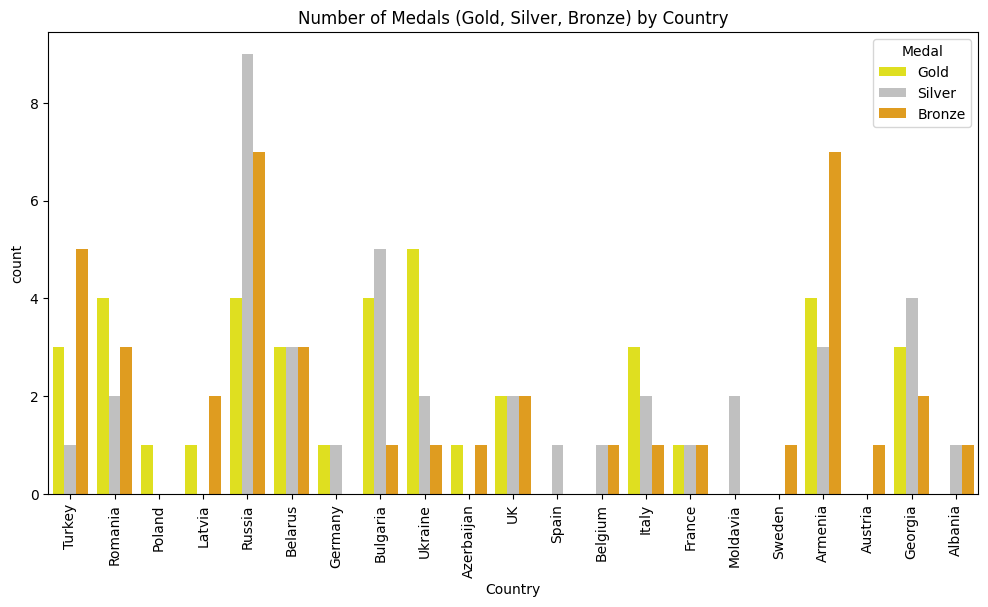

In [49]:
order_medals = ["Gold", "Silver", "Bronze"]

plt.figure(figsize=(12, 6))
sns.countplot(x="Country", 
              data=df, 
              hue="Medal",
              hue_order=order_medals,
              palette=["yellow", "silver", "Orange"])
plt.title("Number of Medals (Gold, Silver, Bronze) by Country")
plt.xticks(rotation=90)
plt.show()

### Which country has achieved the greatest equality in terms of success between its female and male athletes (taking into account the overall number of medals)

In [50]:
medals_pivot = pd.pivot_table(
    df,
    values="Medal",
    index="Country",
    columns="Gender",
    aggfunc="count"
)

medals_pivot = medals_pivot.fillna(0)
medals_pivot

Gender,Femenine,Masculine
Country,,
Albania,0.0,2.0
Armenia,2.0,12.0
Austria,1.0,0.0
Azerbaijan,1.0,1.0
Belarus,2.0,7.0
Belgium,2.0,0.0
Bulgaria,3.0,7.0
France,2.0,1.0
Georgia,0.0,9.0


In [51]:
#Calculate the difference between the men's and women's medals and create a new column called “Difference”

medals_pivot["Difference"] = medals_pivot["Masculine"] - medals_pivot["Femenine"]
medals_pivot["Difference"] = abs(medals_pivot["Difference"]) #absolute value

In [52]:
#Find the country with the smallest difference

min_difference = medals_pivot["Difference"].min()
min_difference

0.0

In [53]:
highest_equity = medals_pivot[medals_pivot["Difference"] == 0.0]
highest_equity

Gender,Femenine,Masculine,Difference
Country,,,
Azerbaijan,1.0,1.0,0.0
Germany,1.0,1.0,0.0
Moldavia,1.0,1.0,0.0


## STEP 1 FINISHES HERE

In [54]:
#Renaming the DataFrame for clarity in Step 2

df_step_1 = df

# **Fase 2.** Web scraping

## Step 1. Importing libraries

In [55]:
from bs4 import BeautifulSoup
!pip install bs4
!pip install requests
import requests

## Paso 2. Cargar datos

In [56]:

#uploading the tables from years: 2022, 2023 and 2024 to complete the analysis

urls = {
    "2022": "https://es.wikipedia.org/wiki/Campeonato_Europeo_de_Halterofilia_de_2022",
    "2023": "https://es.wikipedia.org/wiki/Campeonato_Europeo_de_Halterofilia_de_2023",
    "2024": "https://es.wikipedia.org/wiki/Campeonato_Europeo_de_Halterofilia_de_2024"
}

#creating a dictionary
table_per_year = {}

headers = {
    "User-Agent": "Mozilla/5.0"
}

for year, url in urls.items():
    try:
        response = requests.get(url, headers=headers)

        if response.status_code == 200:
            tables = pd.read_html(response.text)
            table_per_year[year] = tables

        else: 
            print("Error status code")
        
    except Exception as e:
        print(f"Error when processing the URL {url}: {e}")

        

C:\Users\Usuario\AppData\Local\Temp\ipykernel_7844\2018247440.py:21: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(response.text)
C:\Users\Usuario\AppData\Local\Temp\ipykernel_7844\2018247440.py:21: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(response.text)
C:\Users\Usuario\AppData\Local\Temp\ipykernel_7844\2018247440.py:21: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(response.text)


In [57]:
table_per_year

{'2022': [   Campeonato Europeo de Halterofilia Tirana 2022  \
  0                                    Halterofilia   
  1                                 Datos generales   
  2                                            Sede   
  3                                         Recinto   
  4                                       Categoría   
  5                                           Fecha   
  6                                         Edición   
  7                                     Organizador   
  8                              Datos estadísticos   
  9                                   Participantes   
  10                                            NaN   
  11                                     Cronología   
  12            Moscú 2021 Tirana 2022  Ereván 2023   
  13                                     Moscú 2021   
  14                     [editar datos en Wikidata]   
  
     Campeonato Europeo de Halterofilia Tirana 2022.1  \
  0                                      Halterofili

In [58]:
#making sure the code works properly

for year, table in table_per_year.items():
    if year == "2022":
        print(table[2].head())


          Evento                                   Unnamed: 1  \
0  55 kg (29.05)  Anguel Rusev Bulgaria  113 + 144 = 257[n 1]   
1  61 kg (29.05)         Ivan Dimov Bulgaria  135 + 151 = 286   
2  67 kg (30.05)  Valentin Guenchev Bulgaria  139 + 175 = 314   
3  73 kg (31.05)      Muhammed Özbek Turquía  149 + 190 = 339   
4  81 kg (01.06)   Rafik Harutiunian Armenia  160 + 194 = 354   

                                         Unnamed: 2  \
0  Josué Brachi García España  115 + 141 = 256[n 1]   
1        Simon Brandhuber Alemania  134 + 152 = 286   
2        Shota Mishvelidze Georgia  142 + 165 = 307   
3            Kaji Asanidze Georgia  150 + 176 = 326   
4         Andrés Mata Pérez España  160 + 186 = 346   

                                         Unnamed: 3  
0   Dmytro Voronovsky Ucrania  108 + 134 = 242[n 1]  
1         Gabriel Marinov Bulgaria  122 + 157 = 279  
2  Acorán Hernández Mendoza España  138 + 161 = 299  
3          Piotr Kudłaszyk Polonia  143 + 181 = 324  
4       

In [59]:
#convert the required tables into data frames

df_2022_masculine = pd.DataFrame(table_per_year["2022"][2])
df_2022_femenine = pd.DataFrame(table_per_year["2022"][3])

df_2023_masculine = pd.DataFrame(table_per_year["2023"][2])
df_2023_femenine = pd.DataFrame(table_per_year["2023"][3])

df_2024_masculine = pd.DataFrame(table_per_year["2024"][2])
df_2024_femenine = pd.DataFrame(table_per_year["2024"][3])


Normalizing the DFs so that they have the same format as the DFs from year 2019 and 2021

In [60]:
#adding the "gender" column

dictionary_df_femenine = {'2022': df_2022_femenine, '2023': df_2023_femenine, '2024': df_2024_femenine}


for k, v in dictionary_df_femenine.items():
    v["Gender"] = "Femenine"



In [61]:
dictionary_df_masculine = {'2022': df_2022_masculine, '2023': df_2023_masculine, '2024': df_2024_masculine}


for k, v in dictionary_df_masculine.items():
    v["Gender"] = "Masculine"

In [62]:
#concatenate the DFs

df_2022 = pd.concat([df_2022_masculine, df_2022_femenine])
df_2023 = pd.concat([df_2023_masculine, df_2023_femenine])
df_2024 = pd.concat([df_2024_masculine, df_2024_femenine])

In [63]:
#adding the "Year" column 

df_2022["Year"] = "2022"
df_2023["Year"] = "2023"
df_2024["Year"] = "2024"

## Paso 3. Exploración inicial

In [64]:
initial_exploration(df_2022)

¿How many rows and columns are there in the dataset?
	There are 20 rows and 6 columns.

########################################################################################
What are the first five rows of the dataset?


,Evento,Unnamed: 1,Unnamed: 2,Unnamed: 3,Gender,Year
0,55 kg (29.05),Anguel Rusev Bulgaria 113 + 144 = 257[n 1],Josué Brachi García España 115 + 141 = 256[n 1],Dmytro Voronovsky Ucrania 108 + 134 = 242[n 1],Masculine,2022
1,61 kg (29.05),Ivan Dimov Bulgaria 135 + 151 = 286,Simon Brandhuber Alemania 134 + 152 = 286,Gabriel Marinov Bulgaria 122 + 157 = 279,Masculine,2022
2,67 kg (30.05),Valentin Guenchev Bulgaria 139 + 175 = 314,Shota Mishvelidze Georgia 142 + 165 = 307,Acorán Hernández Mendoza España 138 + 161 = 299,Masculine,2022
3,73 kg (31.05),Muhammed Özbek Turquía 149 + 190 = 339,Kaji Asanidze Georgia 150 + 176 = 326,Piotr Kudłaszyk Polonia 143 + 181 = 324,Masculine,2022
4,81 kg (01.06),Rafik Harutiunian Armenia 160 + 194 = 354,Andrés Mata Pérez España 160 + 186 = 346,Bozhidar Andreev Bulgaria 153 + 190 = 343,Masculine,2022



########################################################################################
What are the last five rows of the dataset?


,Evento,Unnamed: 1,Unnamed: 2,Unnamed: 3,Gender,Year
5,71 kg (01.06),Patricia Strenius Suecia 94 + 130 = 224,Lisa Marie Schweizer Alemania 103 + 120 = 223,Monika Marach Polonia 99 + 116 = 215,Femenine,2022
6,76 kg (02.06),Marie Fegue Francia 110 + 135 = 245,Daniela Ivanova Letonia 96 + 126 = 222,Dilara Ucan Turquía 99 + 121 = 220,Femenine,2022
7,81 kg (03.06),Iryna Deja Ucrania 116 + 137 = 253,Alina Marushchak Ucrania 108 + 127 = 235,Dilara Narin Turquía 99 + 133 = 232,Femenine,2022
8,87 kg (04.06),Solfrid Koanda Noruega 109 + 143 = 252,Anastasiya Manievska Ucrania 107 + 130 = 237,Anastasiya Hotfrid Georgia 106 + 129 = 235,Femenine,2022
9,+87 kg (05.06),Emily Campbell Reino Unido 118 + 153 = 271,Melike Günal Turquía 108 + 134 = 242,Sarah Fischer Austria 102 + 128 = 230,Femenine,2022



########################################################################################
How can you obtain a random sample of rows from the dataset?


,Evento,Unnamed: 1,Unnamed: 2,Unnamed: 3,Gender,Year
7,81 kg (03.06),Iryna Deja Ucrania 116 + 137 = 253,Alina Marushchak Ucrania 108 + 127 = 235,Dilara Narin Turquía 99 + 133 = 232,Femenine,2022
8,87 kg (04.06),Solfrid Koanda Noruega 109 + 143 = 252,Anastasiya Manievska Ucrania 107 + 130 = 237,Anastasiya Hotfrid Georgia 106 + 129 = 235,Femenine,2022
8,109 kg (04.06),Jristo Jristov Bulgaria 180 + 211 = 391,Guiorgui Chjeidze Georgia 174 + 210 = 384,Arsen Martirosian Armenia 170 + 201 = 371,Masculine,2022
6,96 kg (03.06),Davit Hovhannisian Armenia 171 + 206 = 377,Ara Aghanian Armenia 170 + 205 = 375,Romain Imadouchène Francia 160 + 210 = 370,Masculine,2022
4,64 kg (31.05),Mariya Hanhur Ucrania 102 + 120 = 222,Nuray Güngör Turquía 99 + 120 = 219,Vicky Graillot Francia 89 + 119 = 208,Femenine,2022



########################################################################################
What are the columns in the dataset?
	 - Evento
	 - Unnamed: 1
	 - Unnamed: 2
	 - Unnamed: 3
	 - Gender
	 - Year

########################################################################################
What is the data type for each column?
Evento        object
Unnamed: 1    object
Unnamed: 2    object
Unnamed: 3    object
Gender        object
Year          object
dtype: object

########################################################################################
How many columns are there for each type of data?
object    6
Name: count, dtype: int64

########################################################################################
How can we get more complete information about the structure and contents of the DataFrame?
<class 'pandas.core.frame.DataFrame'>
Index: 20 entries, 0 to 9
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      -------------- 

,Evento,Unnamed: 1,Unnamed: 2,Unnamed: 3,Gender,Year
count,20,20,20,20,20,20
unique,19,20,20,20,2,1
top,55 kg (29.05),Anguel Rusev Bulgaria 113 + 144 = 257[n 1],Josué Brachi García España 115 + 141 = 256[n 1],Dmytro Voronovsky Ucrania 108 + 134 = 242[n 1],Masculine,2022
freq,2,1,1,1,10,20



########################################################################################
Are there any null values in the dataset?
Evento        0
Unnamed: 1    0
Unnamed: 2    0
Unnamed: 3    0
Gender        0
Year          0
dtype: int64

########################################################################################
What is the percentage of missing values in each column?
Evento        0.0
Unnamed: 1    0.0
Unnamed: 2    0.0
Unnamed: 3    0.0
Gender        0.0
Year          0.0
dtype: float64

########################################################################################


In [65]:
initial_exploration(df_2023)

¿How many rows and columns are there in the dataset?
	There are 20 rows and 6 columns.

########################################################################################
What are the first five rows of the dataset?


,Evento,Unnamed: 1,Unnamed: 2,Unnamed: 3,Gender,Year
0,55 kg (16.04),Anguel Rusev Bulgaria 109 + 141 = 250[n 1],Ramin Shamilishvili Georgia 113 + 136 = 249[n 1],Valentin Iancu Rumania 109 + 136 = 245[n 1],Masculine,2023
1,61 kg (16.04),Shota Mishvelidze Georgia 136 + 162 = 298,Sergio Massidda Italia 130 + 162 = 292,Ivan Dimov Bulgaria 127 + 150 = 277,Masculine,2023
2,67 kg (17.04),Gor Sahakian Armenia 145 + 175 = 320,Acorán Hernández Mendoza España 140 + 165 = 305,Kaan Kahriman Turquía 141 + 160 = 301,Masculine,2023
3,73 kg (18.04),Ritvars Suharevs Letonia 152 + 184 = 336,David Sánchez López España 150 + 185 = 335,Mirko Zanni Italia 155 + 180 = 335,Masculine,2023
4,81 kg (19.04),Oscar Reyes Martínez Italia 155 + 188 = 343,Batu Han Yüksel Turquía 152 + 187 = 339,Rafik Harutiunian Armenia 150 + 187 = 337,Masculine,2023



########################################################################################
What are the last five rows of the dataset?


,Evento,Unnamed: 1,Unnamed: 2,Unnamed: 3,Gender,Year
5,71 kg (19.04),Loredana Toma Rumania 110 + 130 = 240,Giulia Miserendino Italia 105 + 125 = 230,Sarah Davies Reino Unido 100 + 126 = 226,Femenine,2023
6,76 kg (20.04),Marie Fegue Francia 113 + 140 = 253,Tatev Hakobian Armenia 104 + 122 = 226,Daniela Ivanova Letonia 96 + 126 = 222,Femenine,2023
7,81 kg (21.04),Iryna Deja Ucrania 123 + 135 = 258,Dilara Narin Turquía 101 + 134 = 235,Elena Erighina Moldavia 104 + 130 = 234,Femenine,2023
8,87 kg (22.04),Solfrid Koanda Noruega 117 + 155 = 272,Anastasiya Manievska Ucrania 108 + 130 = 238,Hripsime Jurshudian Armenia 107 + 120 = 227,Femenine,2023
9,+87 kg (23.04),Emily Campbell Reino Unido 110 + 143 = 253,Anastasiya Hotfrid Georgia 117+ 135 = 252,Valentyna Kisil Ucrania 111 + 133 = 244,Femenine,2023



########################################################################################
How can you obtain a random sample of rows from the dataset?


,Evento,Unnamed: 1,Unnamed: 2,Unnamed: 3,Gender,Year
2,67 kg (17.04),Gor Sahakian Armenia 145 + 175 = 320,Acorán Hernández Mendoza España 140 + 165 = 305,Kaan Kahriman Turquía 141 + 160 = 301,Masculine,2023
7,102 kg (22.04),Garik Karapetian Armenia 178 + 214 = 392,Irakli Chjeidze Georgia 173 + 214 = 387,Tudor Bratu Moldavia 170 + 204 = 374,Masculine,2023
1,61 kg (16.04),Shota Mishvelidze Georgia 136 + 162 = 298,Sergio Massidda Italia 130 + 162 = 292,Ivan Dimov Bulgaria 127 + 150 = 277,Masculine,2023
6,76 kg (20.04),Marie Fegue Francia 113 + 140 = 253,Tatev Hakobian Armenia 104 + 122 = 226,Daniela Ivanova Letonia 96 + 126 = 222,Femenine,2023
6,96 kg (21.04),Davit Hovhannisian Armenia 172 + 205 = 377,Ara Aghanian Armenia 165 + 199 = 364,Cristiano Ficco Italia 165 + 198 = 363,Masculine,2023



########################################################################################
What are the columns in the dataset?
	 - Evento
	 - Unnamed: 1
	 - Unnamed: 2
	 - Unnamed: 3
	 - Gender
	 - Year

########################################################################################
What is the data type for each column?
Evento        object
Unnamed: 1    object
Unnamed: 2    object
Unnamed: 3    object
Gender        object
Year          object
dtype: object

########################################################################################
How many columns are there for each type of data?
object    6
Name: count, dtype: int64

########################################################################################
How can we get more complete information about the structure and contents of the DataFrame?
<class 'pandas.core.frame.DataFrame'>
Index: 20 entries, 0 to 9
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      -------------- 

,Evento,Unnamed: 1,Unnamed: 2,Unnamed: 3,Gender,Year
count,20,20,20,20,20,20
unique,19,20,20,20,2,1
top,55 kg (16.04),Anguel Rusev Bulgaria 109 + 141 = 250[n 1],Ramin Shamilishvili Georgia 113 + 136 = 249[n 1],Valentin Iancu Rumania 109 + 136 = 245[n 1],Masculine,2023
freq,2,1,1,1,10,20



########################################################################################
Are there any null values in the dataset?
Evento        0
Unnamed: 1    0
Unnamed: 2    0
Unnamed: 3    0
Gender        0
Year          0
dtype: int64

########################################################################################
What is the percentage of missing values in each column?
Evento        0.0
Unnamed: 1    0.0
Unnamed: 2    0.0
Unnamed: 3    0.0
Gender        0.0
Year          0.0
dtype: float64

########################################################################################


In [66]:
initial_exploration(df_2024)

¿How many rows and columns are there in the dataset?
	There are 20 rows and 6 columns.

########################################################################################
What are the first five rows of the dataset?


,Evento,Unnamed: 1,Unnamed: 2,Unnamed: 3,Gender,Year
0,55 kg (13.02),Anguel Rusev Bulgaria 109 + 135 = 244[n 1],Ramin Shamilishvili Georgia 111 + 130 = 241[n 1],Dzhan Zarkov Bulgaria 102 + 133 = 235[n 1],Masculine,2024
1,61 kg (13.02),Gabriel Marinov Bulgaria 121 + 160 = 281,Ivan Dimov Bulgaria 130 + 150 = 280,Shota Mishvelidze Georgia 125 + 147 = 272,Masculine,2024
2,67 kg (14.02),Gor Sahakian Armenia 140 + 171 = 311,Kaan Kahriman Turquía 142 + 168 = 310,Ferdi Hardal Turquía 135 + 169 = 304,Masculine,2024
3,73 kg (15.02),Bozhidar Andreev Bulgaria 155 + 193 = 348,Muhammed Özbek Turquía 150 + 186 = 336,Ritvars Suharevs Letonia 154 + 177 = 331,Masculine,2024
4,81 kg (16.02),Oscar Reyes Martínez Italia 155 + 191 = 346,Kristi Ramadani Albania 151 + 190 = 341,Rafik Harutiunian Armenia 154 + 182 = 336,Masculine,2024



########################################################################################
What are the last five rows of the dataset?


,Evento,Unnamed: 1,Unnamed: 2,Unnamed: 3,Gender,Year
5,71 kg (16.02),Loredana Toma Rumania 114 + 127 = 241,Siuzanna Valadzko AIN[a 1] 105 + 130 = 235,Lisa Marie Schweizer Alemania 107 + 124 = 231,Femenine,2024
6,76 kg (17.02),Genna Toko Kegne Italia 101 + 120 = 221,Nikol Rubanovich Israel 99 + 117 = 216,Lara Dancz Alemania 101 + 114 = 215,Femenine,2024
7,81 kg (18.02),Weronika Zielińska-Stubińska Polonia 103 + 13...,Elena Erighina Moldavia 103+ 131 = 234,Dilara Narin Turquía 97 + 125 = 222,Femenine,2024
8,87 kg (19.02),Solfrid Koanda Noruega 120 + 160 = 280,Anastasiya Manievska Ucrania 102 + 128 = 230,Hripsime Jurshudian Armenia 105 + 122 = 227,Femenine,2024
9,+87 kg (20.02),Emily Campbell Reino Unido 112 + 151 = 263,Anastasiya Hotfrid Georgia 117 + 140 = 257,Fatmagül Çevik Turquía 107 + 131 = 238,Femenine,2024



########################################################################################
How can you obtain a random sample of rows from the dataset?


,Evento,Unnamed: 1,Unnamed: 2,Unnamed: 3,Gender,Year
5,71 kg (16.02),Loredana Toma Rumania 114 + 127 = 241,Siuzanna Valadzko AIN[a 1] 105 + 130 = 235,Lisa Marie Schweizer Alemania 107 + 124 = 231,Femenine,2024
4,64 kg (15.02),Hanna Davydova Ucrania 100 + 120 = 220,Svitlana Samuliak Ucrania 101 + 118 = 219,Wiktoria Wołk Polonia 94 + 121 = 215,Femenine,2024
0,55 kg (13.02),Anguel Rusev Bulgaria 109 + 135 = 244[n 1],Ramin Shamilishvili Georgia 111 + 130 = 241[n 1],Dzhan Zarkov Bulgaria 102 + 133 = 235[n 1],Masculine,2024
6,76 kg (17.02),Genna Toko Kegne Italia 101 + 120 = 221,Nikol Rubanovich Israel 99 + 117 = 216,Lara Dancz Alemania 101 + 114 = 215,Femenine,2024
3,59 kg (14.02),Kamila Konotop Ucrania 105 + 125 = 230,Dora Tchakounté Francia 98 + 117 = 215,Saara Retulainen Finlandia 95 + 119 = 214,Femenine,2024



########################################################################################
What are the columns in the dataset?
	 - Evento
	 - Unnamed: 1
	 - Unnamed: 2
	 - Unnamed: 3
	 - Gender
	 - Year

########################################################################################
What is the data type for each column?
Evento        object
Unnamed: 1    object
Unnamed: 2    object
Unnamed: 3    object
Gender        object
Year          object
dtype: object

########################################################################################
How many columns are there for each type of data?
object    6
Name: count, dtype: int64

########################################################################################
How can we get more complete information about the structure and contents of the DataFrame?
<class 'pandas.core.frame.DataFrame'>
Index: 20 entries, 0 to 9
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      -------------- 

,Evento,Unnamed: 1,Unnamed: 2,Unnamed: 3,Gender,Year
count,20,20,20,20,20,20
unique,19,20,20,20,2,1
top,55 kg (13.02),Anguel Rusev Bulgaria 109 + 135 = 244[n 1],Ramin Shamilishvili Georgia 111 + 130 = 241[n 1],Dzhan Zarkov Bulgaria 102 + 133 = 235[n 1],Masculine,2024
freq,2,1,1,1,10,20



########################################################################################
Are there any null values in the dataset?
Evento        0
Unnamed: 1    0
Unnamed: 2    0
Unnamed: 3    0
Gender        0
Year          0
dtype: int64

########################################################################################
What is the percentage of missing values in each column?
Evento        0.0
Unnamed: 1    0.0
Unnamed: 2    0.0
Unnamed: 3    0.0
Gender        0.0
Year          0.0
dtype: float64

########################################################################################


## Step 4. Create a single dataframe containing the data for 2019, 2020, 2021, 2022, 2023 and 2024

In order to concatenate the data frames, changes will need to be made to df_2022, df_2023 and df_2024 

They must be in the same format as df_2019 and df_2021

In [67]:
dfs_dictionary = {'2022': df_2022, '2023': df_2023, '2024': df_2024}

In [68]:
df_2022.columns

Index(['Evento', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Gender', 'Year'], dtype='object')

In [69]:
#change the column names

for k, v in dfs_dictionary.items():
    v.rename(columns={'Unnamed: 1': 'Gold'}, inplace=True)
    v.rename(columns={'Unnamed: 2': 'Silver'}, inplace=True)
    v.rename(columns={'Unnamed: 3': 'Bronze'}, inplace=True)
    v.rename(columns={'Evento': 'Events'}, inplace=True)


In [70]:
df_step_2 = pd.concat(dfs_dictionary.values(), ignore_index=True)

In [71]:
df_step_2.head()

,Events,Gold,Silver,Bronze,Gender,Year
0,55 kg (29.05),Anguel Rusev Bulgaria 113 + 144 = 257[n 1],Josué Brachi García España 115 + 141 = 256[n 1],Dmytro Voronovsky Ucrania 108 + 134 = 242[n 1],Masculine,2022
1,61 kg (29.05),Ivan Dimov Bulgaria 135 + 151 = 286,Simon Brandhuber Alemania 134 + 152 = 286,Gabriel Marinov Bulgaria 122 + 157 = 279,Masculine,2022
2,67 kg (30.05),Valentin Guenchev Bulgaria 139 + 175 = 314,Shota Mishvelidze Georgia 142 + 165 = 307,Acorán Hernández Mendoza España 138 + 161 = 299,Masculine,2022
3,73 kg (31.05),Muhammed Özbek Turquía 149 + 190 = 339,Kaji Asanidze Georgia 150 + 176 = 326,Piotr Kudłaszyk Polonia 143 + 181 = 324,Masculine,2022
4,81 kg (01.06),Rafik Harutiunian Armenia 160 + 194 = 354,Andrés Mata Pérez España 160 + 186 = 346,Bozhidar Andreev Bulgaria 153 + 190 = 343,Masculine,2022


In [72]:
df_step_1["Country"].unique()

array(['Turkey', 'Romania', 'Poland', 'Latvia', 'Russia', 'Belarus',
       'Germany', 'Bulgaria', 'Ukraine', 'Azerbaijan', 'UK', 'Spain',
       'Belgium', 'Italy', 'France', 'Moldavia', 'Sweden', 'Armenia',
       'Austria', 'Georgia', 'Albania'], dtype=object)

In [73]:
#Countries' names are in Spanish. I will replace them with corresponding English names as in the DFs from year 2019 and 2021.

In [74]:
translation_countries = {
    "Alemania": "Germany",
    "Francia": "France",
    "España": "Spain",
    "Italia": "Italy",
    "Reino Unido" : "UK",
    "Rusia" : "Russia",
    "Turquía" : "Turkey",
    "Letonia" : "Latvia",
    "Ucrania" : "Ukraine",
    "Bélgica" : "Belgium",
    "Noruega" : "Norway",
    "Suecia" : "Sweden",
    "Polonia" : "Poland",
    "Ucrania" : "Ukraine",
    "AIN" : "Belarus"
    }

columns_to_translate = ["Gold", "Silver", "Bronze"]

for col in columns_to_translate:
    df_step_2[col] = df_step_2[col].replace(translation_countries, regex=True) #regex=True looks for pieces of text inside a sentence, instead of looking for the whole sentence.

In [75]:
df_step_2.head()

,Events,Gold,Silver,Bronze,Gender,Year
0,55 kg (29.05),Anguel Rusev Bulgaria 113 + 144 = 257[n 1],Josué Brachi García Spain 115 + 141 = 256[n 1],Dmytro Voronovsky Ukraine 108 + 134 = 242[n 1],Masculine,2022
1,61 kg (29.05),Ivan Dimov Bulgaria 135 + 151 = 286,Simon Brandhuber Germany 134 + 152 = 286,Gabriel Marinov Bulgaria 122 + 157 = 279,Masculine,2022
2,67 kg (30.05),Valentin Guenchev Bulgaria 139 + 175 = 314,Shota Mishvelidze Georgia 142 + 165 = 307,Acorán Hernández Mendoza Spain 138 + 161 = 299,Masculine,2022
3,73 kg (31.05),Muhammed Özbek Turkey 149 + 190 = 339,Kaji Asanidze Georgia 150 + 176 = 326,Piotr Kudłaszyk Poland 143 + 181 = 324,Masculine,2022
4,81 kg (01.06),Rafik Harutiunian Armenia 160 + 194 = 354,Andrés Mata Pérez Spain 160 + 186 = 346,Bozhidar Andreev Bulgaria 153 + 190 = 343,Masculine,2022


In [76]:
#normalise the df_step_2 so that it has the same columns as the df from step 1

print(df_step_2.columns)
print(df_step_1.columns)

Index(['Events', 'Gold', 'Silver', 'Bronze', 'Gender', 'Year'], dtype='object')
Index(['Gender', 'Category', 'Date', 'Medal', 'Name', 'Surname', 'Country',
       'Sprint', 'Two_stroke', 'Total'],
      dtype='object')


In [77]:
#Perform the same data cleaning as was done with df_step_1

df_step_2 = columns_medals(df_step_2)

In [78]:
split_columns(df_step_2)

,Events,Year,Gender,Medal,Athlete,Category,Date,Name,Surname,Country,Aux_column,Sprint,Two_stroke,Total
0,55 kg (29.05),2022,Masculine,Gold,Anguel Rusev Bulgaria 113 + 144 = 257[n 1],55 kg,29.05),Anguel,Rusev,Bulgaria,144 = 257[n 1],113,144,257[n 1]
1,61 kg (29.05),2022,Masculine,Gold,Ivan Dimov Bulgaria 135 + 151 = 286,61 kg,29.05),Ivan,Dimov,Bulgaria,151 = 286,135,151,286
2,67 kg (30.05),2022,Masculine,Gold,Valentin Guenchev Bulgaria 139 + 175 = 314,67 kg,30.05),Valentin,Guenchev,Bulgaria,175 = 314,139,175,314
3,73 kg (31.05),2022,Masculine,Gold,Muhammed Özbek Turkey 149 + 190 = 339,73 kg,31.05),Muhammed,Özbek,Turkey,190 = 339,149,190,339
4,81 kg (01.06),2022,Masculine,Gold,Rafik Harutiunian Armenia 160 + 194 = 354,81 kg,01.06),Rafik,Harutiunian,Armenia,194 = 354,160,194,354
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,71 kg (16.02),2024,Femenine,Bronze,Lisa Marie Schweizer Germany 107 + 124 = 231,71 kg,16.02),Lisa,Marie,Schweizer,124 = 231,Germany 107,124,231
176,76 kg (17.02),2024,Femenine,Bronze,Lara Dancz Germany 101 + 114 = 215,76 kg,17.02),Lara,Dancz,Germany,114 = 215,101,114,215
177,81 kg (18.02),2024,Femenine,Bronze,Dilara Narin Turkey 97 + 125 = 222,81 kg,18.02),Dilara,Narin,Turkey,125 = 222,97,125,222
178,87 kg (19.02),2024,Femenine,Bronze,Hripsime Jurshudian Armenia 105 + 122 = 227,87 kg,19.02),Hripsime,Jurshudian,Armenia,122 = 227,105,122,227


In [79]:
df_step_2 = df_step_2.drop(columns=["Aux_column"])

In [80]:
#concatenate the "Date" and "Year" columns

df_step_2["Date"] = df_step_2["Date"].str.replace(")", "")
df_step_2["Date"] = df_step_2["Date"].astype(str)
df_step_2["Date"] = df_step_2["Date"] + "." + df_step_2["Year"].astype(str)


In [81]:
#remove blank spaces
df_step_2 = df_step_2.apply(lambda x: x.str.strip() if x.dtype == "object" else x)

In [82]:
#keeping only the necessary columns

df_step_2 = df_step_2[["Gender", "Category", "Date", "Medal", "Name", "Surname", "Country", "Sprint", "Two_stroke", "Total"]]

In [83]:
df_step_2["Country"].unique()

array(['Bulgaria', 'Turkey', 'Armenia', 'Italy', 'Georgia', 'Albania',
       'France', 'Ukraine', 'Sweden', 'Norway', 'UK', 'Latvia',
       'Martínez', 'Rumania', 'Belarus[a', 'Azerbaiyán', 'Kegne',
       'Poland', 'García', 'Germany', 'Pérez', 'Schweizer', 'Mendoza',
       'López', 'Yüksel', 'Belgium', 'Israel', 'Moldavia', 'Velasco',
       'Serbia', 'Spain', 'Austria', 'Rincón', 'Irlanda', 'Waaler',
       'Finlandia'], dtype=object)

In [84]:
df_step_2["Country"] = df_step_2["Country"].astype(str).str.replace("[a", "", regex=False)

In [85]:
checking_unique_values(df_step_2)

Columna: Gender
['Masculine' 'Femenine']
__________________________
Columna: Category
['55\xa0kg' '61\xa0kg' '67\xa0kg' '73\xa0kg' '81\xa0kg' '89\xa0kg'
 '96\xa0kg' '102\xa0kg' '109\xa0kg' '+109\xa0kg' '45\xa0kg' '49\xa0kg'
 '59\xa0kg' '64\xa0kg' '71\xa0kg' '76\xa0kg' '87\xa0kg' '+87\xa0kg']
__________________________
Columna: Date
['29.05.2022' '30.05.2022' '31.05.2022' '01.06.2022' '02.06.2022'
 '03.06.2022' '04.06.2022' '05.06.2022' '28.05.2022' '16.04.2023'
 '17.04.2023' '18.04.2023' '19.04.2023' '20.04.2023' '21.04.2023'
 '22.04.2023' '23.04.2023' '15.04.2023' '13.02.2024' '14.02.2024'
 '15.02.2024' '16.02.2024' '17.02.2024' '18.02.2024' '19.02.2024'
 '20.02.2024' '12.02.2024']
__________________________
Columna: Medal
['Gold' 'Silver' 'Bronze']
__________________________
Columna: Name
['Anguel' 'Ivan' 'Valentin' 'Muhammed' 'Rafik' 'Antonino' 'Davit' 'David'
 'Jristo' 'Lasha' 'Şaziye' 'Giulia' 'Evagjelia' 'Dora' 'Mariya' 'Patricia'
 'Marie' 'Iryna' 'Solfrid' 'Emily' 'Shota' 'Gor' 

In [86]:
#removing some unnecesary values in the columns

df_step_2["Category"] = df_step_2["Category"].str.split("\xa0kg").str[0]
df_step_2["Category"] = df_step_2["Category"] + " kg"
df_step_2["Sprint"] = df_step_2["Sprint"].astype(str).str.replace("1]", "")
df_step_2["Total"] = df_step_2["Total"].astype(str).str.replace("[n 1]", "")

In [87]:
checking_unique_values(df_step_2)

Columna: Gender
['Masculine' 'Femenine']
__________________________
Columna: Category
['55 kg' '61 kg' '67 kg' '73 kg' '81 kg' '89 kg' '96 kg' '102 kg' '109 kg'
 '+109 kg' '45 kg' '49 kg' '59 kg' '64 kg' '71 kg' '76 kg' '87 kg'
 '+87 kg']
__________________________
Columna: Date
['29.05.2022' '30.05.2022' '31.05.2022' '01.06.2022' '02.06.2022'
 '03.06.2022' '04.06.2022' '05.06.2022' '28.05.2022' '16.04.2023'
 '17.04.2023' '18.04.2023' '19.04.2023' '20.04.2023' '21.04.2023'
 '22.04.2023' '23.04.2023' '15.04.2023' '13.02.2024' '14.02.2024'
 '15.02.2024' '16.02.2024' '17.02.2024' '18.02.2024' '19.02.2024'
 '20.02.2024' '12.02.2024']
__________________________
Columna: Medal
['Gold' 'Silver' 'Bronze']
__________________________
Columna: Name
['Anguel' 'Ivan' 'Valentin' 'Muhammed' 'Rafik' 'Antonino' 'Davit' 'David'
 'Jristo' 'Lasha' 'Şaziye' 'Giulia' 'Evagjelia' 'Dora' 'Mariya' 'Patricia'
 'Marie' 'Iryna' 'Solfrid' 'Emily' 'Shota' 'Gor' 'Ritvars' 'Oscar'
 'Karlos' 'Garik' 'Samvel' 'Cansu' '

In [88]:
#There are some values in the Sprint column where the country name appears. This might be due to the fact that some athletes have more than one name/surname

df_aux = df_step_2[df_step_2["Sprint"].str.contains(r"[a-zA-Z]+\s+\d+", regex=True)]

df_aux

,Gender,Category,Date,Medal,Name,Surname,Country,Sprint,Two_stroke,Total
24,Masculine,81 kg,19.04.2023,Gold,Oscar,Reyes,Martínez,Italy 155,188,343
44,Masculine,81 kg,16.02.2024,Gold,Oscar,Reyes,Martínez,Italy 155,191,346
56,Femenine,76 kg,17.02.2024,Gold,Genna,Toko,Kegne,Italy 101,120,221
60,Masculine,55 kg,29.05.2022,Silver,Josué,Brachi,García,Spain 115,141,256
64,Masculine,81 kg,01.06.2022,Silver,Andrés,Mata,Pérez,Spain 160,186,346
75,Femenine,71 kg,01.06.2022,Silver,Lisa,Marie,Schweizer,Germany 103,120,223
82,Masculine,67 kg,17.04.2023,Silver,Acorán,Hernández,Mendoza,Spain 140,165,305
83,Masculine,73 kg,18.04.2023,Silver,David,Sánchez,López,Spain 150,185,335
84,Masculine,81 kg,19.04.2023,Silver,Batu,Han,Yüksel,Turkey 152,187,339
122,Masculine,67 kg,30.05.2022,Bronze,Acorán,Hernández,Mendoza,Spain 138,161,299


In [89]:
df_aux[["Country_aux", "Sprint_aux"]] = df_aux["Sprint"].astype(str).str.split(r"\s+", expand=True) 

C:\Users\Usuario\AppData\Local\Temp\ipykernel_7844\42125573.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_aux[["Country_aux", "Sprint_aux"]] = df_aux["Sprint"].astype(str).str.split(r"\s+", expand=True)
C:\Users\Usuario\AppData\Local\Temp\ipykernel_7844\42125573.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_aux[["Country_aux", "Sprint_aux"]] = df_aux["Sprint"].astype(str).str.split(r"\s+", expand=True)


In [90]:
df_aux.head()

,Gender,Category,Date,Medal,Name,Surname,Country,Sprint,Two_stroke,Total,Country_aux,Sprint_aux
24,Masculine,81 kg,19.04.2023,Gold,Oscar,Reyes,Martínez,Italy 155,188,343,Italy,155
44,Masculine,81 kg,16.02.2024,Gold,Oscar,Reyes,Martínez,Italy 155,191,346,Italy,155
56,Femenine,76 kg,17.02.2024,Gold,Genna,Toko,Kegne,Italy 101,120,221,Italy,101
60,Masculine,55 kg,29.05.2022,Silver,Josué,Brachi,García,Spain 115,141,256,Spain,115
64,Masculine,81 kg,01.06.2022,Silver,Andrés,Mata,Pérez,Spain 160,186,346,Spain,160


In [91]:
df_aux["Sprint"] = df_aux["Sprint_aux"]

C:\Users\Usuario\AppData\Local\Temp\ipykernel_7844\224204480.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_aux["Sprint"] = df_aux["Sprint_aux"]


In [92]:
df_aux.head()

,Gender,Category,Date,Medal,Name,Surname,Country,Sprint,Two_stroke,Total,Country_aux,Sprint_aux
24,Masculine,81 kg,19.04.2023,Gold,Oscar,Reyes,Martínez,155,188,343,Italy,155
44,Masculine,81 kg,16.02.2024,Gold,Oscar,Reyes,Martínez,155,191,346,Italy,155
56,Femenine,76 kg,17.02.2024,Gold,Genna,Toko,Kegne,101,120,221,Italy,101
60,Masculine,55 kg,29.05.2022,Silver,Josué,Brachi,García,115,141,256,Spain,115
64,Masculine,81 kg,01.06.2022,Silver,Andrés,Mata,Pérez,160,186,346,Spain,160


In [93]:
df_aux["Surname"] = df_aux["Surname"] + " " + df_aux["Country"]
df_aux["Country"] = df_aux["Country_aux"]

C:\Users\Usuario\AppData\Local\Temp\ipykernel_7844\4286580616.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_aux["Surname"] = df_aux["Surname"] + " " + df_aux["Country"]
C:\Users\Usuario\AppData\Local\Temp\ipykernel_7844\4286580616.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_aux["Country"] = df_aux["Country_aux"]


In [94]:
df_aux = df_aux.drop(columns=["Country_aux", "Sprint_aux"])
df_aux.head()

,Gender,Category,Date,Medal,Name,Surname,Country,Sprint,Two_stroke,Total
24,Masculine,81 kg,19.04.2023,Gold,Oscar,Reyes Martínez,Italy,155,188,343
44,Masculine,81 kg,16.02.2024,Gold,Oscar,Reyes Martínez,Italy,155,191,346
56,Femenine,76 kg,17.02.2024,Gold,Genna,Toko Kegne,Italy,101,120,221
60,Masculine,55 kg,29.05.2022,Silver,Josué,Brachi García,Spain,115,141,256
64,Masculine,81 kg,01.06.2022,Silver,Andrés,Mata Pérez,Spain,160,186,346


In [95]:
df_step_2.update(df_aux)

In [96]:
#checking if the values were updated

df_step_2.iloc[24]

Gender             Masculine
Category               81 kg
Date              19.04.2023
Medal                   Gold
Name                   Oscar
Surname       Reyes Martínez
Country                Italy
Sprint                   155
Two_stroke               188
Total                    343
Name: 24, dtype: object

In [97]:
#converting the data types so that it matches the df_step_1

df_step_2["Date"] = pd.to_datetime(df_step_2["Date"], format="%d.%m.%Y", errors='coerce') 
df_step_2["Sprint"] = df_step_2["Sprint"].astype(int)
df_step_2["Two_stroke"] = df_step_2["Two_stroke"].astype(int)
df_step_2["Total"] = df_step_2["Total"].astype(int)
df_step_2["Category"] = df_step_2["Category"].astype("category")
df_step_2["Medal"] = df_step_2["Medal"].astype("category")

The two DFs are identical now. We can concatenate them. 

In [98]:
df_final = pd.concat([df_step_1, df_step_2], axis=0)

In [99]:
df_final.head(2)

,Gender,Category,Date,Medal,Name,Surname,Country,Sprint,Two_stroke,Total
0,Femenine,45 kg,2019-04-06,Gold,Şaziye,Erdoğan,Turkey,75,88,163
1,Femenine,49 kg,2019-04-06,Gold,Elena,Andrieș,Romania,87,103,190


## Step 10. EDA
Carrying out an exploratory analysis of the data to gain an understanding of the dataset before answering the questions

In [100]:
df_final.describe()

,Date,Sprint,Two_stroke,Total
count,300,300.000000,300.000000,300.000000
mean,2022-01-27 18:14:24,128.253333,155.543333,284.136667
min,2019-04-06 00:00:00,65.000000,11.000000,150.000000
25%,2021-04-04 18:00:00,99.000000,120.000000,221.000000
50%,2022-06-01 00:00:00,114.000000,141.000000,254.500000
75%,2023-04-21 06:00:00,162.250000,196.000000,360.750000
max,2024-02-20 00:00:00,222.000000,263.000000,485.000000
std,NaN,37.785557,45.084255,81.919640


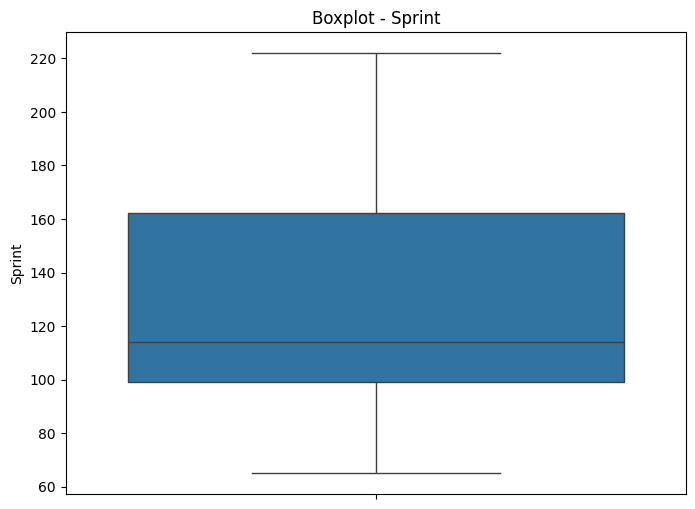

In [101]:
# Identifying Outliers in Sprint

plt.figure(figsize=(8, 6))
sns.boxplot(y=df_final["Sprint"])
plt.title("Boxplot - Sprint")
plt.show()


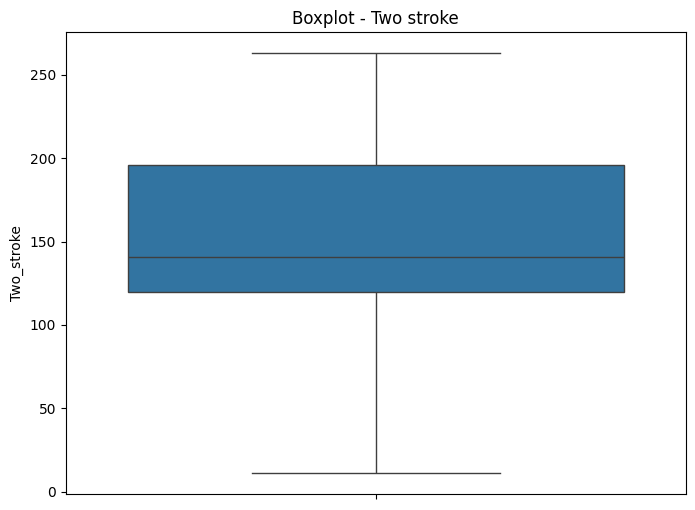

In [102]:
# Identifying Outliers in Two_stroke

plt.figure(figsize=(8, 6))
sns.boxplot(y=df_final["Two_stroke"])
plt.title("Boxplot - Two stroke")
plt.show()


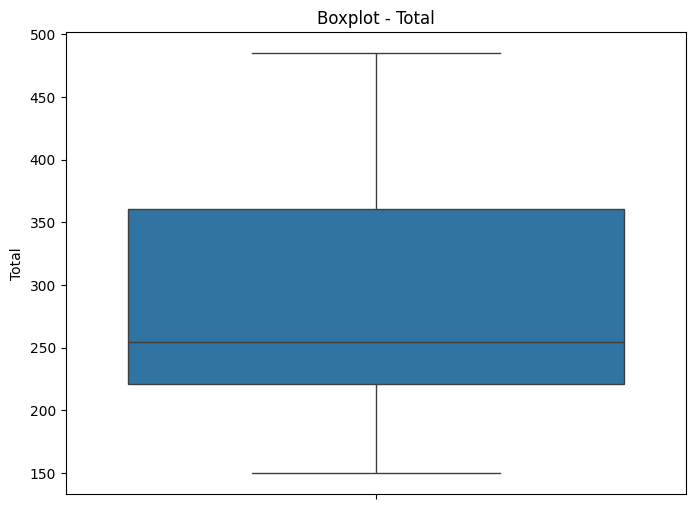

In [103]:
# Identifying Outliers in Total
plt.figure(figsize=(8, 6))
sns.boxplot(y=df_final["Total"])
plt.title("Boxplot - Total")
plt.show()


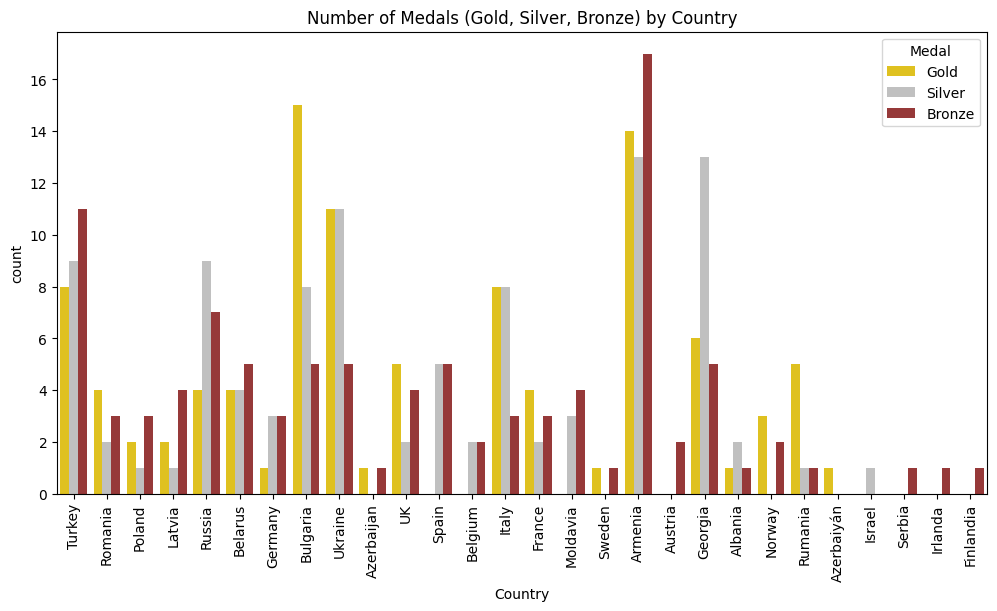

In [104]:
# Bar chart showing the number of medals (Gold, Silver, Bronze) by country

order = ["Gold", "Silver", "Bronze"]

plt.figure(figsize=(12, 6))
sns.countplot(x="Country", 
              data=df_final, 
              hue="Medal",
              hue_order=order,
              palette=["gold", "silver", "brown"])
plt.title('Number of Medals (Gold, Silver, Bronze) by Country')
plt.xticks(rotation=90)
plt.show()


C:\Users\Usuario\AppData\Local\Temp\ipykernel_7844\908158728.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Gender',


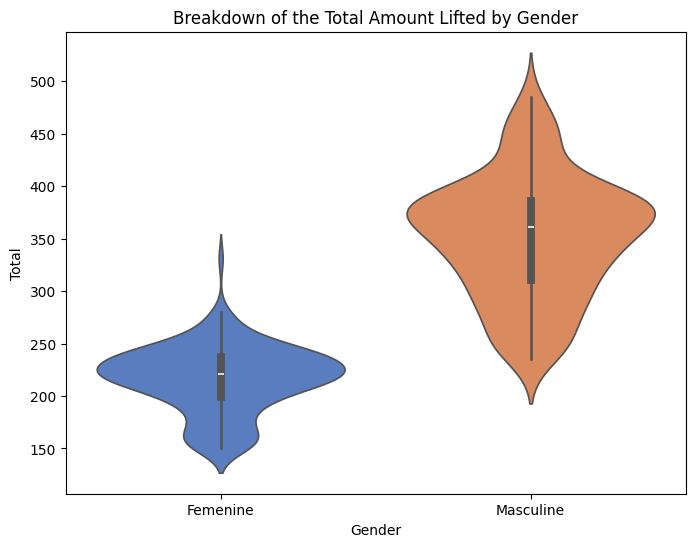

In [105]:
#Breakdown of the Total Amount Lifted by Gender

plt.figure(figsize=(8, 6))
sns.violinplot(x='Gender', 
               y='Total', 
               data=df_final, 
               palette='muted')
plt.title("Breakdown of the Total Amount Lifted by Gender")
plt.show()



## **Questions to be answered**

### How many medals of each type (gold, silver and bronze) has each country won in the competition? (Not taking gender into account)

In [106]:
df_final.groupby(["Country", "Medal"]).size().reset_index(name="Medal amount")

,Country,Medal,Medal amount
0,Albania,Bronze,1
1,Albania,Gold,1
2,Albania,Silver,2
3,Armenia,Bronze,17
4,Armenia,Gold,14
...,...,...,...
61,UK,Gold,5
62,UK,Silver,2
63,Ukraine,Bronze,5
64,Ukraine,Gold,11


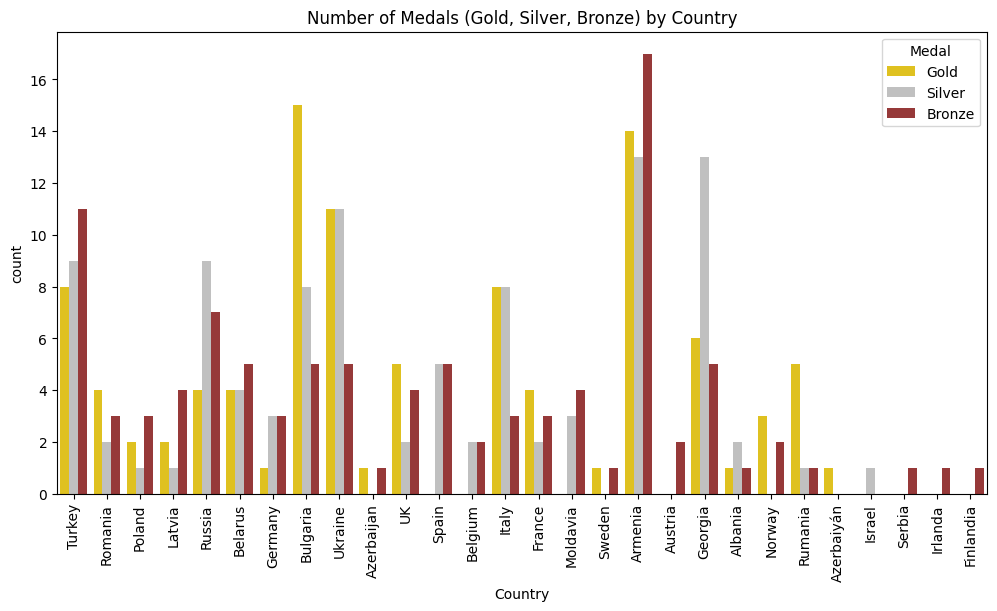

In [107]:
order = ["Gold", "Silver", "Bronze"]

plt.figure(figsize=(12, 6))
sns.countplot(x="Country", 
              data=df_final, 
              hue="Medal",
              hue_order=order,
              palette=["gold", "silver", "brown"])
plt.title('Number of Medals (Gold, Silver, Bronze) by Country')
plt.xticks(rotation=90)
plt.show()


### Which country has achieved the greatest equity in terms of the success of its female and male athletes?

In [108]:
medals_pivot = pd.pivot_table(
    df_final,
    values="Medal",
    index="Country",
    columns="Gender",
    aggfunc="count"
)

medals_pivot = medals_pivot.fillna(0)
medals_pivot

Gender,Femenine,Masculine
Country,,
Albania,1.0,3.0
Armenia,7.0,37.0
Austria,2.0,0.0
Azerbaijan,1.0,1.0
Azerbaiyán,0.0,1.0
Belarus,3.0,10.0
Belgium,4.0,0.0
Bulgaria,3.0,25.0
Finlandia,1.0,0.0


In [109]:
#Calculate the difference between the men's and women's medals and create a new column called “Difference”

medals_pivot["Difference"] = medals_pivot["Masculine"] - medals_pivot["Femenine"]
medals_pivot["Difference"] = abs(medals_pivot["Difference"]) #absolute value

In [110]:
min_difference = medals_pivot["Difference"].min()
min_difference

0.0

In [111]:
highest_equity = medals_pivot[medals_pivot["Difference"] == 0.0]
highest_equity

Gender,Femenine,Masculine,Difference
Country,,,
Azerbaijan,1.0,1.0,0.0


# Data for the final presentation

In [112]:
df_final.tail(2)

,Gender,Category,Date,Medal,Name,Surname,Country,Sprint,Two_stroke,Total
178,Femenine,87 kg,2024-02-19,Bronze,Hripsime,Jurshudian,Armenia,105,122,227
179,Femenine,+87 kg,2024-02-20,Bronze,Fatmagül,Çevik,Turkey,107,131,238


In [113]:
df_final["Country"].nunique()

28

In [114]:
df_final["Category"].nunique()

18

In [115]:
#charts: year vs average total lifted by gender

df_final["Date"] = pd.to_datetime(df_final["Date"])  
df_final["Year"] = df_final["Date"].dt.year  # Extraer el año

# Calculate the average of the totals by year, gender = male
df_masculine = df_final[df_final["Gender"] == "Masculine"]
df_masculine_groupped = df_masculine.groupby("Year")["Total"].mean().reset_index()

# Calculate the average of the totals by year, gender = female
df_femenine = df_final[df_final["Gender"] == "Femenine"]
df_femenine_groupped = df_femenine.groupby("Year")["Total"].mean().reset_index()

print(df_masculine_groupped)
print("___________________")
print(df_femenine_groupped)


   Year       Total
0  2019  354.766667
1  2021  356.466667
2  2022  349.800000
3  2023  349.433333
4  2024  347.866667
___________________
   Year       Total
0  2019  218.833333
1  2021  217.900000
2  2022  213.566667
3  2023  217.633333
4  2024  215.100000


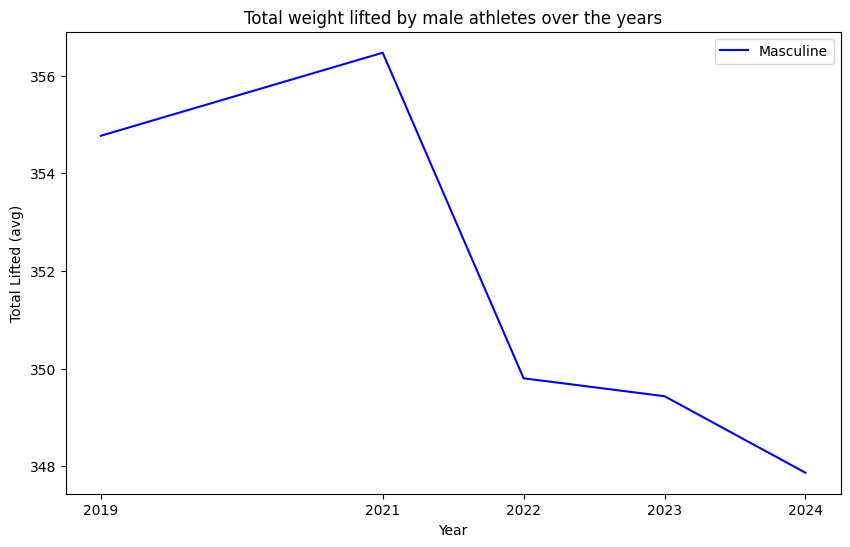

In [123]:
#charts: year vs average total lifted by gender


# Creating a chart for men only
plt.figure(figsize=(10, 6))
plt.plot(df_masculine_groupped["Year"], 
         df_masculine_groupped["Total"],
         label="Masculine", 
         color="blue")

plt.title("Total weight lifted by male athletes over the years")
plt.xlabel("Year")
plt.ylabel("Total Lifted (avg)")
plt.xticks([2019, 2021, 2022, 2023, 2024])

plt.legend()
plt.show()

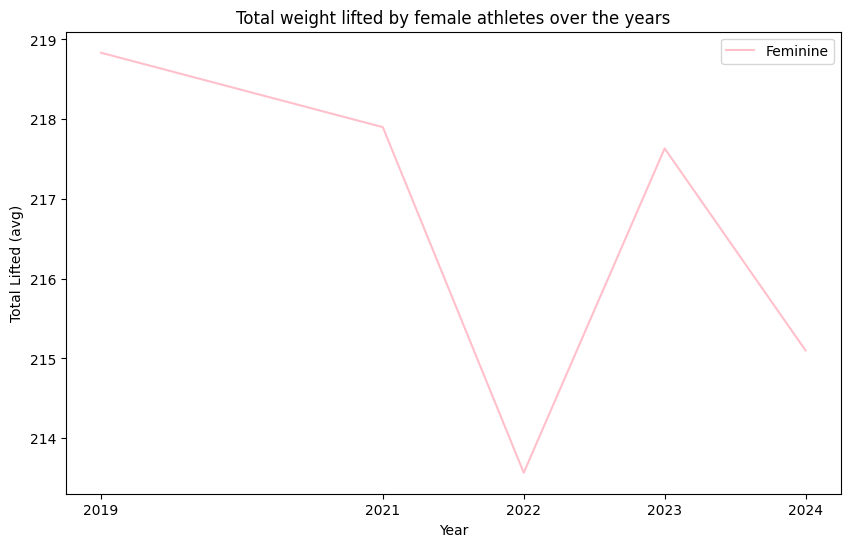

In [122]:
#charts: year vs average total lifted by gender

# Creating a chart for women only
plt.figure(figsize=(10, 6))
plt.plot(df_femenine_groupped["Year"], 
         df_femenine_groupped["Total"],
         label="Feminine", 
         color="pink")

plt.title("Total weight lifted by female athletes over the years")
plt.xlabel("Year")
plt.ylabel("Total Lifted (avg)")
plt.xticks([2019, 2021, 2022, 2023, 2024])
plt.legend()
plt.show()

In [124]:
#chart: country vs total amount raised by gender


# Group the data by Year and Country
df_groupped = df_final.groupby(["Year", "Country"])["Total"].sum().reset_index()

# Crear gráfico interactivo
fig = px.line(df_groupped, 
              x="Year", 
              y="Total", 
              color="Country", 
              title="Total Amount Lifted by Country Over the Years",
              labels={"Total": "Total Lifted", "Año": "Year"},
              markers=True)
fig.show()


In [1393]:
#chart: country vs total amount raised by gender


# Group the data by Year and Country
df_groupped = df_final.groupby(["Year", "Country"])["Total"].sum().reset_index()

# Crear gráfico interactivo
fig = px.line(df_groupped, 
              x="Year", 
              y="Total", 
              color="Country", 
              title="Total Amount Lifted by Country Over the Years",
              labels={"Total": "Total Lifted", "Año": "Year"},
              markers=True)

fig.show()

In [1391]:
#chart: Average total lift per medal over the years


# Group the data by Year and Medal
df_medals_groupped = df_final.groupby(["Year", "Medal"])["Total"].mean().reset_index()

# Definir el orden de las medallas
order_medals = ["Gold", "Silver", "Bronze"]

# Colores para las medallas
colors_medals = {
    "Gold": "gold",
    "Silver": "silver",
    "Bronze": "orange"
}

# Crear gráfico
fig = px.line(df_medals_groupped, 
              x="Year", 
              y="Total", 
              color="Medal", 
              title="Total Lifted per Medal Over the Years",
              markers=True,
              category_orders={"Medal": order_medals},  # Orden de las medallas
              color_discrete_map=colors_medals)  # Asignar colores a las medallas

# Mostrar el gráfico interactivo
fig.show()


In [1395]:
df_groupped = df_final.groupby(["Year", "Gender"])["Total"].sum().reset_index()

# Crear gráfico interactivo
fig = px.line(df_groupped, 
              x="Year", 
              y="Total", 
              color="Gender", 
              title="Total Amount Lifted by Country Over the Years",
              labels={"Total": "Total Lifted", "Año": "Year"},
              markers=True)

fig.show()